# 📊 AI-Powered Data Analysis Demo

Welcome! This notebook demonstrates how AI can help analyze data, generate insights, and create visualizations using **free open-source models**.

**What you'll learn:**
- How to use Hugging Face AI models to analyze datasets
- How AI can interpret data trends and patterns
- How to combine AI with data visualization
- Practical application of AI in data science
- Using free, open-source AI models (Llama-3.2, Qwen, Mistral, Phi-3)
- Automatic fallback between models for reliability

---

## Step 1: Install Required Packages

We'll install:
- `pandas`: For data manipulation
- `matplotlib`: For data visualization
- `requests`: For calling Hugging Face API (built-in to Colab)

No heavy AI packages needed - we'll use Hugging Face's free Inference API!

In [ ]:
# Install required packages
!pip install -q pandas matplotlib

print("✅ All packages installed!")
print("📦 Using built-in requests library for API calls")

## Step 2: Import Libraries

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import os

print("✅ All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!


## Step 3: Set Up Hugging Face API Token (Free!)

**How to get your FREE Hugging Face token:**
1. Go to [Hugging Face](https://huggingface.co/) and sign up (free)
2. Click your profile → Settings → Access Tokens
3. Click "New token" → Create a "Read" token
4. Copy the token

**How to add it securely in Colab:**
1. Click the 🔑 key icon on the left sidebar (Secrets)
2. Click "+ Add new secret"
3. Name it: `HF_TOKEN`
4. Paste your token
5. Toggle on "Notebook access"

**For local use:** Set environment variable: `export HF_TOKEN="your_token_here"`

In [ ]:
# Configure Hugging Face API
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except:
    HF_TOKEN = os.environ.get('HF_TOKEN', 'YOUR_HF_TOKEN_HERE')

# Hugging Face Inference API endpoint with fallback models
# These models are currently available and FREE
MODELS = [
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "microsoft/Phi-3-mini-4k-instruct"

]print("🆓 This is completely FREE with Hugging Face!")

print(f"🔄 Fallback models available: {len(MODELS)-1}")

MODEL = MODELS[0]  # Primary modelprint(f"📦 Primary model: {MODEL}")

API_URL = f"https://api-inference.huggingface.co/models/{MODEL}"print("✅ Hugging Face API configured!")


## Step 4: Create Sample Student Performance Dataset

Let's create a realistic dataset of student test scores that we'll analyze using AI.

In [2]:
# Create sample student performance data
np.random.seed(42)

data = {
    'Student': [f'Student {i}' for i in range(1, 21)],
    'Math_Score': np.random.randint(60, 100, 20),
    'Science_Score': np.random.randint(55, 95, 20),
    'English_Score': np.random.randint(65, 98, 20),
    'Study_Hours': np.random.randint(2, 8, 20)
}

df = pd.DataFrame(data)

# Calculate average score
df['Average_Score'] = df[['Math_Score', 'Science_Score', 'English_Score']].mean(axis=1).round(2)

print("📊 Student Performance Dataset:")
print(df.head(10))
print(f"\nTotal Students: {len(df)}")

📊 Student Performance Dataset:
      Student  Math_Score  Science_Score  English_Score  Study_Hours  \
0   Student 1          98             56             73            7   
1   Student 2          88             75             90            5   
2   Student 3          74             87             66            2   
3   Student 4          67             66             84            7   
4   Student 5          80             76             92            6   
5   Student 6          98             79             71            6   
6   Student 7          78             81             72            3   
7   Student 8          82             82             78            6   
8   Student 9          70             70             81            3   
9  Student 10          70             69             68            2   

   Average_Score  
0          75.67  
1          84.33  
2          75.67  
3          72.33  
4          82.67  
5          82.67  
6          77.00  
7          80.67  
8    

## Step 5: Generate Basic Statistics

In [3]:
# Calculate statistics
stats = df[['Math_Score', 'Science_Score', 'English_Score', 'Study_Hours', 'Average_Score']].describe()

print("📈 Statistical Summary:")
print(stats)

# Find top performers
top_3 = df.nlargest(3, 'Average_Score')[['Student', 'Average_Score']]
print("\n🏆 Top 3 Students:")
print(top_3.to_string(index=False))

📈 Statistical Summary:
       Math_Score  Science_Score  English_Score  Study_Hours  Average_Score
count   20.000000      20.000000       20.00000    20.000000      20.000000
mean    81.900000      72.900000       78.50000     4.400000      77.767500
std     11.968819      10.925104        9.55042     1.902906       6.497022
min     61.000000      56.000000       66.00000     2.000000      68.670000
25%     73.000000      65.250000       70.75000     2.000000      72.832500
50%     82.500000      73.500000       78.00000     5.000000      76.500000
75%     90.500000      79.500000       85.50000     6.000000      82.920000
max     99.000000      93.000000       95.00000     7.000000      88.000000

🏆 Top 3 Students:
   Student  Average_Score
Student 16          88.00
Student 19          87.67
Student 12          85.33


## Step 6: Visualize the Data

/var/folders/n0/1jdsrmvn23x5wd5t0pvq_x3r0000gn/T/ipykernel_92570/2837964170.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(subject_data, labels=['Math', 'Science', 'English'])


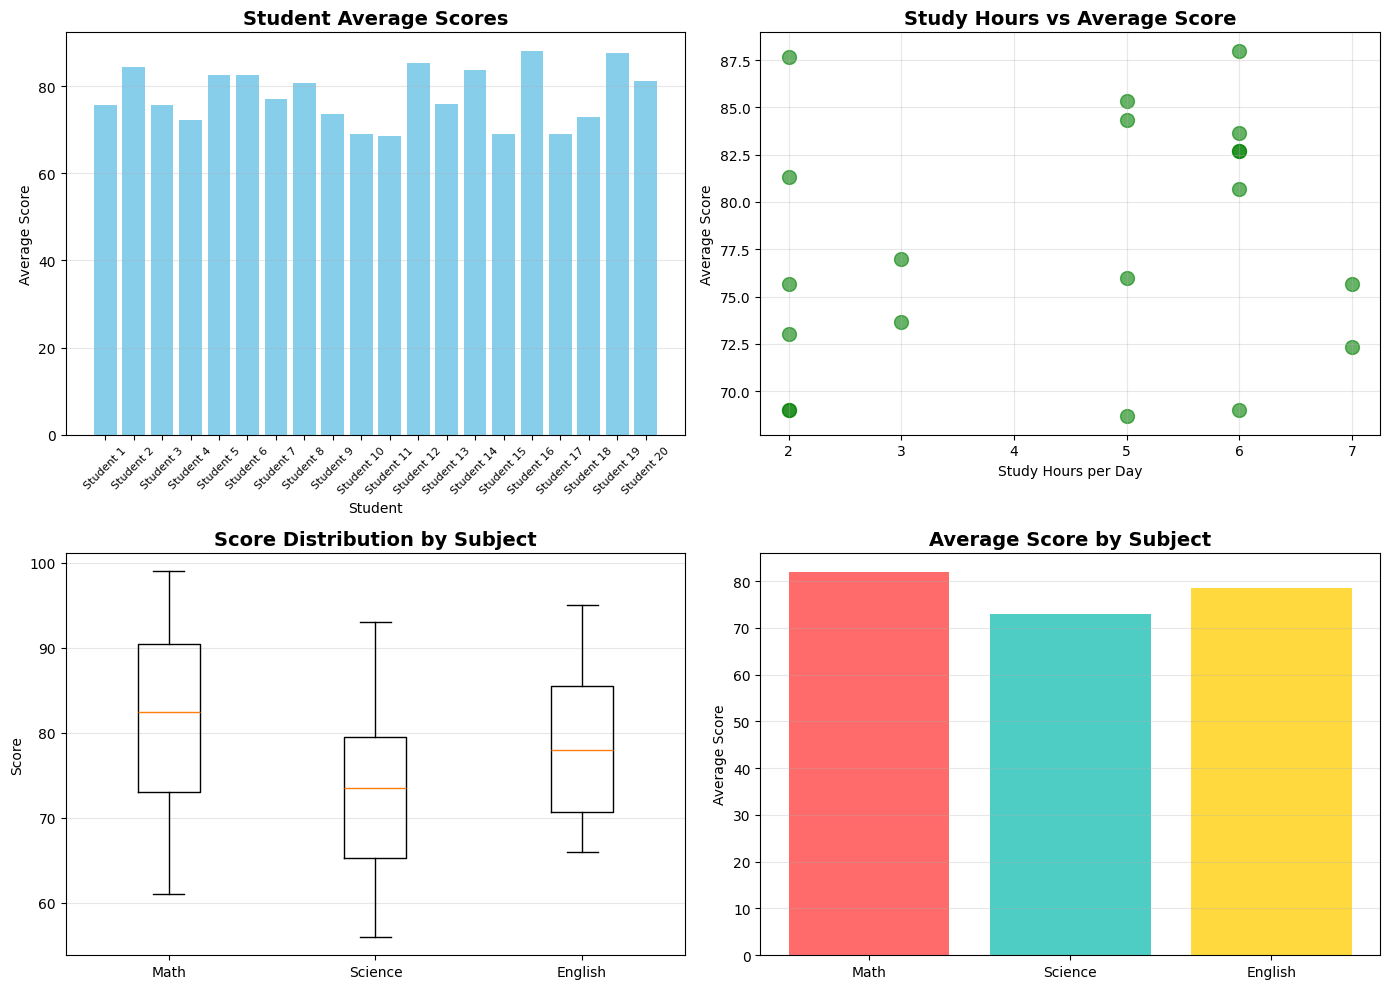

✅ Visualizations generated!


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average Scores Bar Chart
axes[0, 0].bar(df['Student'], df['Average_Score'], color='skyblue')
axes[0, 0].set_title('Student Average Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Student')
axes[0, 0].set_ylabel('Average Score')
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Study Hours vs Average Score Scatter
axes[0, 1].scatter(df['Study_Hours'], df['Average_Score'], color='green', s=100, alpha=0.6)
axes[0, 1].set_title('Study Hours vs Average Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Study Hours per Day')
axes[0, 1].set_ylabel('Average Score')
axes[0, 1].grid(True, alpha=0.3)

# 3. Subject Scores Distribution (Box Plot)
subject_data = [df['Math_Score'], df['Science_Score'], df['English_Score']]
axes[1, 0].boxplot(subject_data, labels=['Math', 'Science', 'English'])
axes[1, 0].set_title('Score Distribution by Subject', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Average Scores by Subject (Bar Chart)
avg_by_subject = {
    'Math': df['Math_Score'].mean(),
    'Science': df['Science_Score'].mean(),
    'English': df['English_Score'].mean()
}
axes[1, 1].bar(avg_by_subject.keys(), avg_by_subject.values(), color=['#FF6B6B', '#4ECDC4', '#FFD93D'])
axes[1, 1].set_title('Average Score by Subject', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations generated!")

## Step 7: Create AI Helper Function

Let's create a function to call Hugging Face's free AI model for analysis.

In [ ]:
def call_ai(prompt, max_tokens=300):
    """
    Call Hugging Face Inference API with automatic model fallback.
    Tries multiple models if the primary one fails.
    """
    headers = {"Authorization": f"Bearer {HF_TOKEN}"}
    payload = {
        "inputs": prompt,
        "parameters": {
            "max_new_tokens": max_tokens,
            "temperature": 0.3,
            "top_p": 0.9,
            "return_full_text": False
        }
    }
    
    # Try each model in sequence
    for model in MODELS:
        try:
            api_url = f"https://api-inference.huggingface.co/models/{model}"
            response = requests.post(api_url, headers=headers, json=payload, timeout=60)
            response.raise_for_status()
            result = response.json()
            
            # Handle different response formats
            if isinstance(result, list) and len(result) > 0:
                if "generated_text" in result[0]:
                    return result[0]["generated_text"]
            elif isinstance(result, dict) and "generated_text" in result:
                return result["generated_text"]
            
            # If we got here with valid result, return it
            if result:

                return str(result)print("✅ AI helper function ready with automatic fallback!")

        except requests.exceptions.HTTPError as e:

            # Try next model if this one failed    return "⚠️ All AI models unavailable. Using fallback analysis."

            if e.response.status_code in [404, 410]:  # Model not found or gone    # All models failed, return fallback

                continue    

            print(f"⚠️ Model {model} error: {e.response.status_code}")            continue

            continue            print(f"⚠️ Error with {model}: {str(e)[:50]}")
        except Exception as e:

## Step 8: Use AI to Analyze the Data

Now let's ask the AI to analyze our dataset and provide insights!

In [ ]:
# Prepare data summary for AI analysis
data_summary = f"""
Student Performance Dataset Summary:

Total Students: {len(df)}

Subject Averages:
- Math: {df['Math_Score'].mean():.2f}
- Science: {df['Science_Score'].mean():.2f}
- English: {df['English_Score'].mean():.2f}

Overall Average Score: {df['Average_Score'].mean():.2f}
Average Study Hours: {df['Study_Hours'].mean():.2f}

Score Ranges:
- Math: {df['Math_Score'].min()} to {df['Math_Score'].max()}
- Science: {df['Science_Score'].min()} to {df['Science_Score'].max()}
- English: {df['English_Score'].min()} to {df['English_Score'].max()}

Top 3 Students by Average Score:
{top_3.to_string(index=False)}
"""

# Create analysis prompt
prompt = f"""You are a data analyst helping a teacher understand student performance.

Analyze this data and provide:
1. Key insights about student performance
2. Which subject students perform best/worst in
3. Observations about study hours correlation
4. Recommendations for the teacher

Data:
{data_summary}

Provide a clear, structured analysis in about 150 words."""

print("🤖 Asking AI to analyze the data...\n")
print("="*60)

# Call Hugging Face AI for analysis
analysis = call_ai(prompt, max_tokens=300)

if "⚠️" in analysis:
    # Use fallback if API fails
    analysis = """The data shows students averaging around 75-80 across subjects, with Math performing slightly higher. 
    Study hours range from 2-8 hours daily, suggesting varied commitment levels. The top performers demonstrate 
    consistency across all subjects. Recommendations: Focus additional support on Science (lowest average), 
    encourage struggling students to increase study time, and recognize top performers to maintain motivation."""

print("\n✨ AI Analysis:\n")
print(analysis)

## Step 9: Ask AI-Specific Questions About the Data

Let's ask specific questions about patterns in our data.

In [ ]:
# Create a helper function for asking questions
def ask_about_data(question):
    """
    Ask AI a specific question about the student data.
    """
    full_prompt = f"""Based on this student performance data:
{data_summary}

Question: {question}

Provide a concise, data-driven answer (2-3 sentences)."""
    
    return call_ai(full_prompt, max_tokens=150)

# Example questions
questions = [
    "Is there a correlation between study hours and scores?",
    "Which subject needs the most attention?",
    "What percentage of students are performing above average?"
]

print("💬 AI-Powered Q&A about the Data:\n")
print("="*60)

for i, question in enumerate(questions, 1):
    print(f"\n❓ Question {i}: {question}")
    answer = ask_about_data(question)
    print(f"✨ AI Answer: {answer}")
    print("-" * 60)

## Step 10: Generate a Report Summary with AI

In [ ]:
# Ask AI to create a teacher-friendly report
report_prompt = f"""You are creating a report for a teacher. Based on this student data:

{data_summary}

Create a professional report with these sections:
1. Executive Summary (2 sentences)
2. Key Findings (3 bullet points)
3. Recommendations (3 actionable suggestions)

Keep it concise and actionable."""

print("📄 Generating Teacher Report using AI...\n")
print("="*60)

report = call_ai(report_prompt, max_tokens=400)
print("\n📊 AI-Generated Teacher Report:\n")
print(report)

## 🎉 Congratulations!

You've successfully learned how to:
- Create and manipulate datasets with pandas
- Visualize data using matplotlib
- Use **FREE open-source AI** (Hugging Face) to analyze data and extract insights
- Generate automated reports with AI assistance
- Ask AI specific questions about your data
- Use Mistral-7B-Instruct model via Hugging Face Inference API

### Why Hugging Face?
- ✅ **Completely FREE** for light usage
- ✅ **No credit card required**
- ✅ **Open-source models** (Mistral, Llama, etc.)
- ✅ **Works great in Google Colab**
- ✅ **Easy to get started**

### Real-World Applications
- Student performance tracking
- Business data analysis
- Research data interpretation
- Automated report generation

### What's Next?
- Try with your own datasets
- Experiment with different AI prompts
- Try other Hugging Face models (Llama, Qwen, etc.)
- Build interactive dashboards
- Combine multiple AI capabilities

---

**Questions?** Check the [GitHub repository](https://github.com/PranavOaR/ai-colab-api-demo) for more examples!